In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Analyze dataset structure

In [2]:
df = pd.read_csv('../data/test/JC-201604-citibike-tripdata.csv')

In [3]:
df.head()

,Trip Duration,Start Time,Stop Time,Start Station ID,Start Station Name,Start Station Latitude,Start Station Longitude,End Station ID,End Station Name,End Station Latitude,End Station Longitude,Bike ID,User Type,Birth Year,Gender
0,2084,2016-04-01 00:16:13,2016-04-01 00:50:58,3203,Hamilton Park,40.727596,-74.044247,3209,Brunswick St,40.724176,-74.050656,24500,Subscriber,1979.0,1
1,324,2016-04-01 00:32:48,2016-04-01 00:38:13,3202,Newport PATH,40.727224,-74.033759,3203,Hamilton Park,40.727596,-74.044247,24475,Subscriber,1954.0,1
2,387,2016-04-01 02:00:33,2016-04-01 02:07:00,3220,5 Corners Library,40.734961,-74.059503,3215,Central Ave,40.746730,-74.049251,24503,Subscriber,1975.0,1
3,140,2016-04-01 02:11:43,2016-04-01 02:14:03,3194,McGinley Square,40.725340,-74.067622,3195,Sip Ave,40.730743,-74.063784,24446,Subscriber,1981.0,1
4,142,2016-04-01 02:18:01,2016-04-01 02:20:23,3195,Sip Ave,40.730743,-74.063784,3194,McGinley Square,40.725340,-74.067622,24446,Subscriber,1981.0,1


In [4]:
df.dtypes

Trip Duration                int64
Start Time                  object
Stop Time                   object
Start Station ID             int64
Start Station Name          object
Start Station Latitude     float64
Start Station Longitude    float64
End Station ID               int64
End Station Name            object
End Station Latitude       float64
End Station Longitude      float64
Bike ID                      int64
User Type                   object
Birth Year                 float64
Gender                       int64
dtype: object

In [5]:
df.shape

(16342, 15)

In [6]:
df.memory_usage(deep=True)

Index                          132
Trip Duration               130736
Start Time                 1111256
Stop Time                  1111256
Start Station ID            130736
Start Station Name         1005683
Start Station Latitude      130736
Start Station Longitude     130736
End Station ID              130736
End Station Name           1007523
End Station Latitude        130736
End Station Longitude       130736
Bike ID                     130736
User Type                   959843
Birth Year                  130736
Gender                      130736
dtype: int64

In [7]:
# Total Memory usage by MB
df.memory_usage(deep=True).sum() / 1024**2

np.float64(6.201794624328613)

#### Fix data types

In [3]:
def optimize_dtypes(df):
    
    # Convert timestamps
    df['Start Time'] = pd.to_datetime(df['Start Time'], errors='coerce')
    df['Stop Time'] = pd.to_datetime(df['Stop Time'], errors='coerce')
    
    # Convert categorical columns
    categorical_cols = [
        'Start Station Name',
        'End Station Name',
        'User Type',
        'Gender'
    ]
    
    for col in categorical_cols:
        df[col] = df[col].astype('category')
        
    # Downcast numeric columns
    numeric_columns = [
        'Trip Duration',
        'Start Station ID',
        'End Station ID',
        'Bike ID'
    ]
    
    for col in numeric_columns:
        df[col] = pd.to_numeric(df[col], downcast='integer')

    
    # Birth Year handling
    # Keep as float if NULLs exist, otherwise convert to int
    if df['Birth Year'].isnull().sum() == 0:
        df['Birth Year'] = df['Birth Year'].astype('int16')
    else:
        df['Birth Year'] = pd.to_numeric(df['Birth Year'], downcast='float')
    
    # Downcast latitude & longitude
    float_cols = [
        'Start Station Latitude',
        'Start Station Longitude',
        'End Station Latitude',
        'End Station Longitude'
    ]
    
    for col in float_cols:
        df[col] = pd.to_numeric(df[col], downcast='float')
    
    return df


# Apply optimization
df = optimize_dtypes(df)


In [9]:
# After optimization, check memory usage again
df.memory_usage(deep=True).sum() / 1024**2

np.float64(0.7865467071533203)

## Identify data quality issues

In [10]:
# NULL values per column
df.isnull().sum()

Trip Duration                 0
Start Time                    0
Stop Time                     0
Start Station ID              0
Start Station Name            0
Start Station Latitude        0
Start Station Longitude       0
End Station ID                0
End Station Name              0
End Station Latitude          0
End Station Longitude         0
Bike ID                       0
User Type                    31
Birth Year                 1749
Gender                        0
dtype: int64

In [13]:
# Check for invalid timestamps (started_at >= ended_at)
invalid_time = df[df['Start Time'] >= df['Stop Time']]
print(f"Invalid time records: {len(invalid_time)}")

Invalid time records: 0


{'whiskers': [<matplotlib.lines.Line2D at 0x1c027814cd0>,
 'caps': [<matplotlib.lines.Line2D at 0x1c027814f50>,
 'boxes': [<matplotlib.lines.Line2D at 0x1c027814b90>],
 'medians': [<matplotlib.lines.Line2D at 0x1c0278151d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x1c027815310>],
 'means': []}

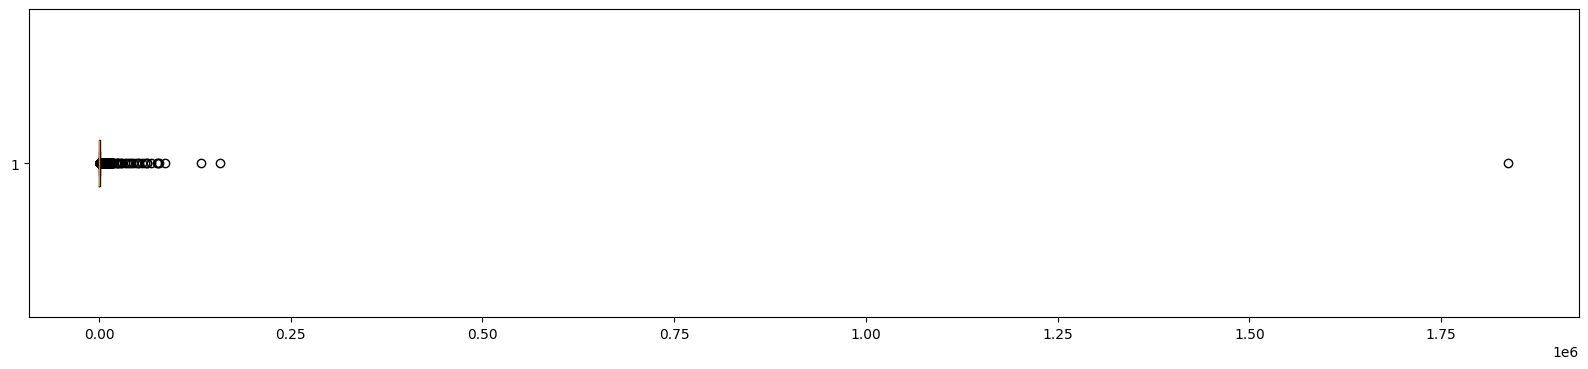

In [17]:
#  Identifing outliers in trip duration
plt.figure(figsize=(20, 4))
plt.boxplot(df['Trip Duration'], vert=False)

In [22]:
# Check coordinate validity (NYC bounds)
def check_coordinates(df):
    lat_bounds = (40.4774, 40.9176)
    lon_bounds = (-74.2591, -73.7004)
    
    invalid_lat = df[
        (df['Start Station Latitude'] < lat_bounds[0]) | 
        (df['Start Station Latitude'] > lat_bounds[1]) |
        (df['End Station Latitude'] < lat_bounds[0]) | 
        (df['End Station Latitude'] > lat_bounds[1])
    ]
    
    invalid_lon = df[
        (df['Start Station Longitude'] < lon_bounds[0]) | 
        (df['Start Station Longitude'] > lon_bounds[1]) |
        (df['End Station Longitude'] < lon_bounds[0]) | 
        (df['End Station Longitude'] > lon_bounds[1])
    ]
    
    print(len(invalid_lat))
    print(len(invalid_lon))
    
check_coordinates(df)

0
0


## Summary statistics

In [23]:
df.describe()

,Trip Duration,Start Time,Stop Time,Start Station ID,Start Station Latitude,Start Station Longitude,End Station ID,End Station Latitude,End Station Longitude,Bike ID,Birth Year
count,1.634200e+04,16342,16342,16342.000000,16342.000000,16342.000000,16342.000000,16342.000000,16342.000000,16342.000000,14593.000000
mean,9.106959e+02,2016-04-18 00:27:07.086892800,2016-04-18 00:42:18.290417408,3198.274263,40.723564,-74.046684,3194.811896,40.723053,-74.045959,24549.015298,1979.145874
min,6.100000e+01,2016-04-01 00:16:13,2016-04-01 00:38:13,3183.000000,40.697029,-74.096939,173.000000,40.697029,-74.096939,14717.000000,1941.000000
25%,2.570000e+02,2016-04-11 21:54:00.500000,2016-04-11 21:58:28.750000128,3186.000000,40.717731,-74.051788,3186.000000,40.716541,-74.050659,24462.000000,1974.000000
50%,4.110000e+02,2016-04-18 19:43:32.500000,2016-04-18 20:07:07.500000,3199.000000,40.721523,-74.044250,3195.000000,40.721123,-74.043846,24558.000000,1981.000000
75%,7.220000e+02,2016-04-24 18:03:28,2016-04-24 18:37:44.750000128,3209.000000,40.727596,-74.036484,3207.000000,40.727596,-74.036484,24641.000000,1986.000000
max,1.837255e+06,2016-04-30 23:56:21,2016-05-19 15:26:09,3225.000000,40.752560,-74.032104,3225.000000,40.784145,-73.980141,24724.000000,1999.000000
std,1.463086e+04,NaN,NaN,11.191773,0.008534,0.012142,87.393009,0.008362,0.012044,212.437284,9.516061


In [24]:
# Number of unique stations
df['Start Station Name'].nunique(), df['End Station Name'].nunique()

(35, 45)

## Visualizations

Text(0.5, 0, 'Duration (seconds)')

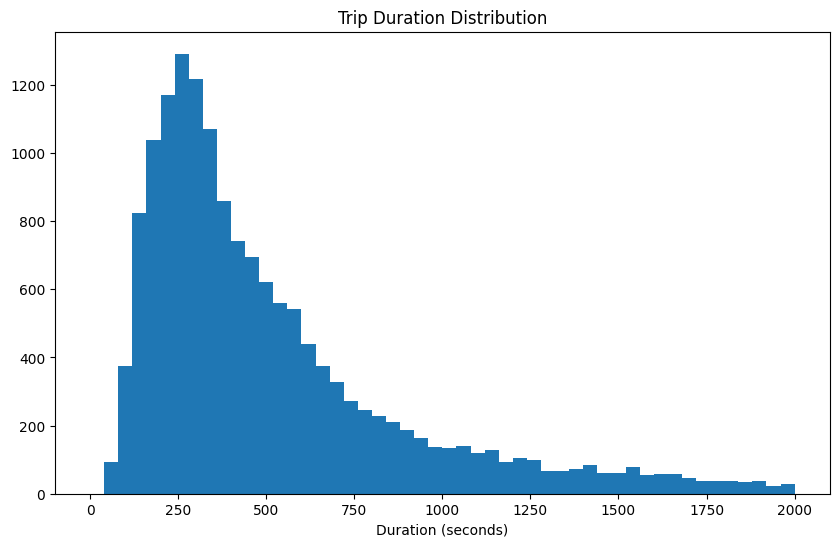

In [25]:
# Trip duration histogram
plt.figure(figsize=(10, 6))
plt.hist(df['Trip Duration'], bins=50, range=(0, 2000))
plt.title('Trip Duration Distribution')
plt.xlabel('Duration (seconds)')

C:\Users\Mega Store\AppData\Local\Temp\ipykernel_18700\2987426236.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='start_hour', y='trip_count', data=hourly_counts, palette='Blues_d')


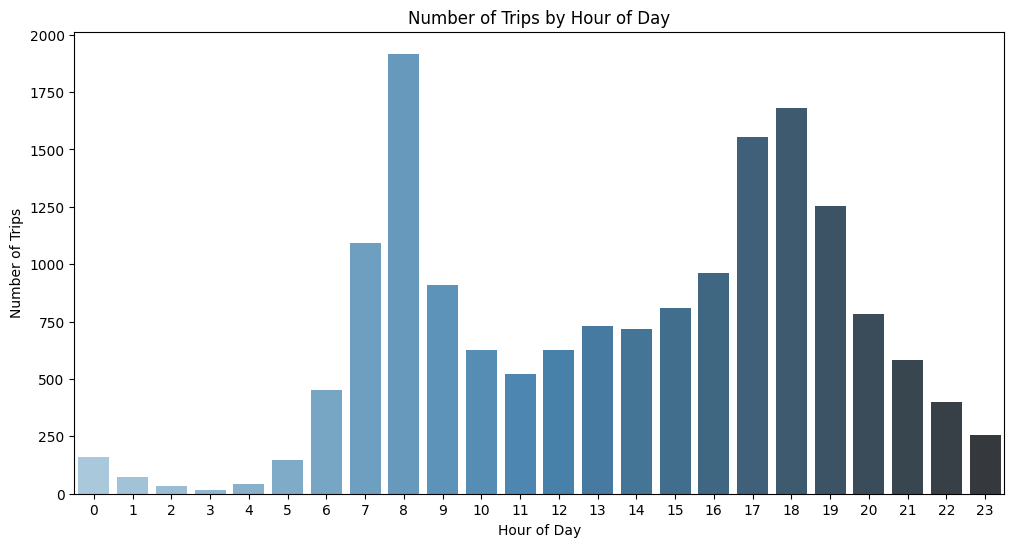

In [ ]:
# Trips by hour of day
df['start_hour'] = df['Start Time'].dt.hour

hourly_counts = df.groupby('start_hour').size().reset_index(name='trip_count')

# Plot
plt.figure(figsize=(12,6))
sns.barplot(x='start_hour', y='trip_count', data=hourly_counts, palette='Blues_d')
plt.title('Number of Trips by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.xticks(range(0,24))
plt.show()

C:\Users\Mega Store\AppData\Local\Temp\ipykernel_29592\2460094955.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='dayofweek', y='trip_count', data=hourly_counts, palette='Blues_d')


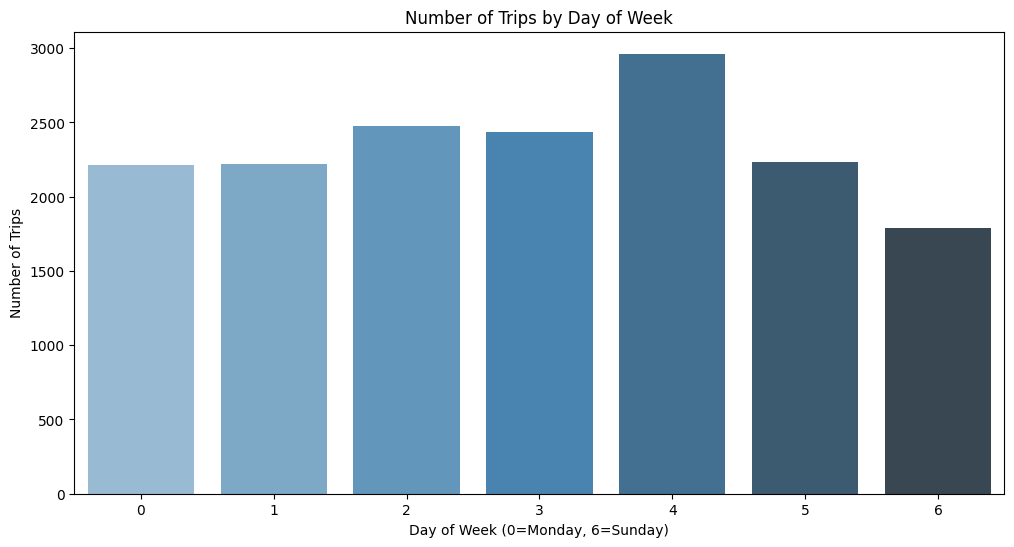

In [4]:
# Trips by day of week
df['dayofweek'] = df['Start Time'].dt.dayofweek

hourly_counts = df.groupby('dayofweek').size().reset_index(name='trip_count')

# Plot
plt.figure(figsize=(12,6))
sns.barplot(x='dayofweek', y='trip_count', data=hourly_counts, palette='Blues_d')
plt.title('Number of Trips by Day of Week')
plt.xlabel('Day of Week (0=Monday, 6=Sunday)')
plt.ylabel('Number of Trips')
plt.xticks(range(0,7))
plt.show()

C:\Users\Mega Store\AppData\Local\Temp\ipykernel_29592\314412341.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='trip_count', y='Start Station Name', data=top_stations, palette='Blues_d')


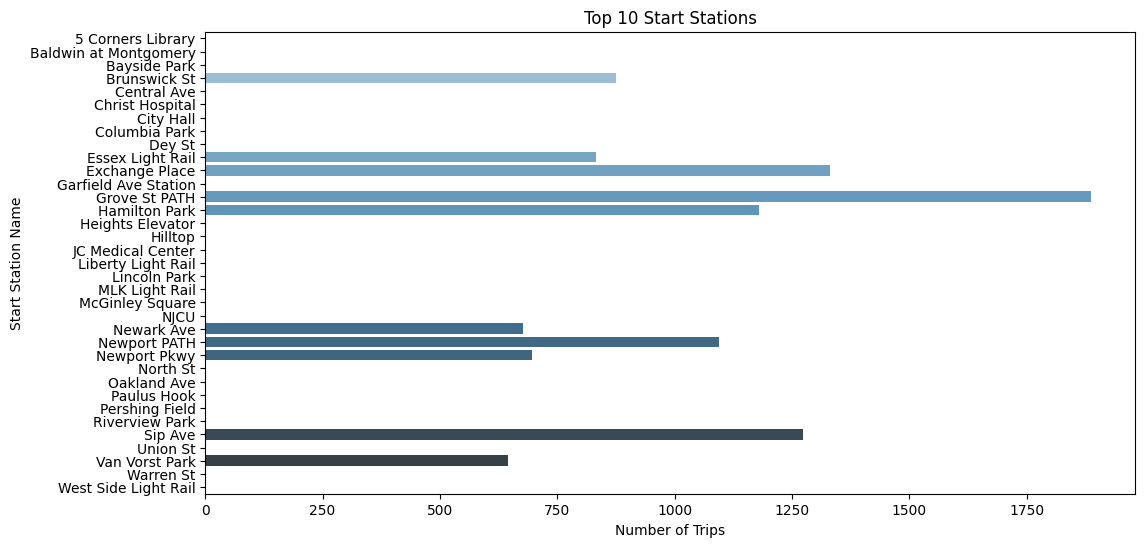

In [8]:
# Top 10 start stations (bar chart)
top_stations = df['Start Station Name'].value_counts().head(10).reset_index()
top_stations.columns = ['Start Station Name', 'trip_count']
plt.figure(figsize=(12,6))
sns.barplot(x='trip_count', y='Start Station Name', data=top_stations, palette='Blues_d')
plt.title('Top 10 Start Stations')
plt.xlabel('Number of Trips')
plt.ylabel('Start Station Name')
plt.show()

C:\Users\Mega Store\AppData\Local\Temp\ipykernel_29592\4260390518.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='User Type', data=df, palette='Blues_d')


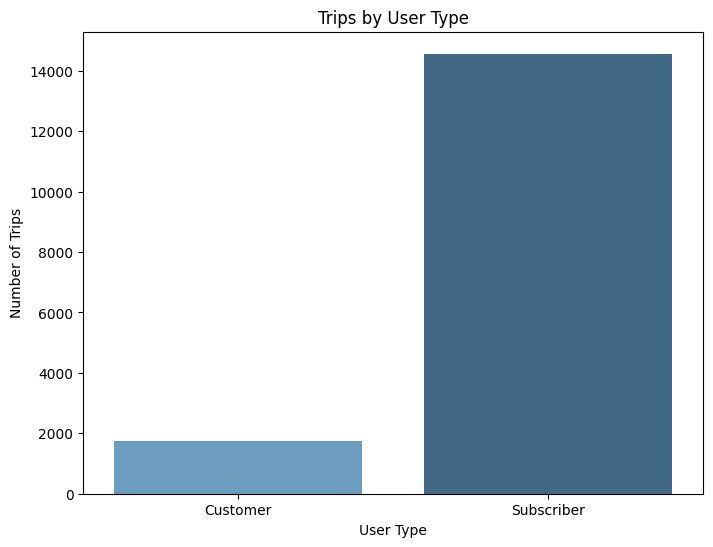

In [9]:
# Member vs casual comparison
plt.figure(figsize=(8,6))
sns.countplot(x='User Type', data=df, palette='Blues_d')
plt.title('Trips by User Type')
plt.xlabel('User Type')
plt.ylabel('Number of Trips')
plt.show()

C:\Users\Mega Store\AppData\Local\Temp\ipykernel_29592\3170149507.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='User Type', y='Trip Duration', data=df, palette='Blues_d')


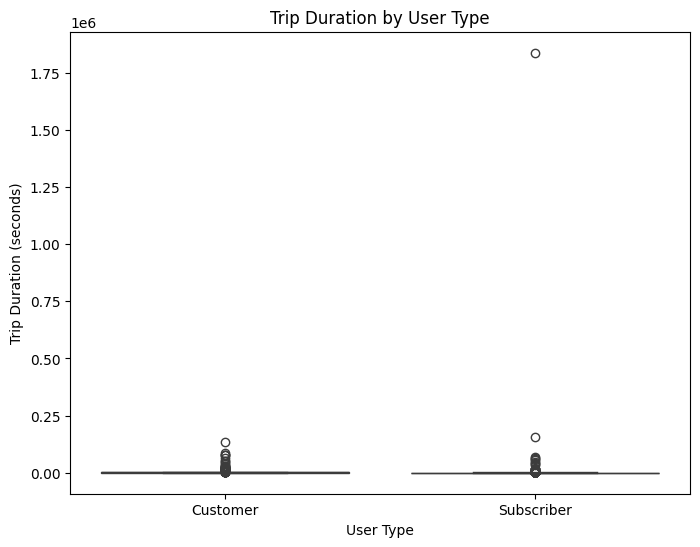

In [10]:
# Trip duration by user type (box plot)
plt.figure(figsize=(8,6))
sns.boxplot(x='User Type', y='Trip Duration', data=df, palette='Blues_d')
plt.title('Trip Duration by User Type')
plt.xlabel('User Type')
plt.ylabel('Trip Duration (seconds)')
plt.show()

## Document findings

- few outliers in trip duration.
- missing values in 'User Type' and 'Birth Year' columns.
- Optimize data types for memory efficiency.